# ITI Retail — Combined Dataset Inventory
## Inspect all candidate sources before another training run
This notebook inventories ZIP files without extracting the full datasets. It does not train, change the current model, merge image folders, or assume that more files mean more independent examples.

Upload these archives directly into `MyDrive/ITI_Retail_Project`:
- fruits-360-100x100-main.zip (already there)
- fruits-360-original-size-main.zip
- fruits-360-3-body-problem-main.zip
- fruits-360-multi-main.zip
- fruits-360-meta-main.zip (metadata reference)

The papers archive is a literature reference and is not needed for image ingestion. CPU is sufficient for this notebook. Wait until all required uploads finish.

The output describes candidate data, not a training-ready dataset. Near-duplicate/capture-group analysis, labeling multi-object crops, and a unified evaluation split must be resolved before training. Source descriptions: https://github.com/fruits-360

Project flow: inventory → review overlap and labels → prepare multi-product images → freeze splits → train CNN and transfer learning → evaluate → update the app. This notebook covers inventory and initial review only.

The code uses ordinary loops, dictionaries, pandas tables, and Python standard-library ZIP/hash functions. `hashlib` computes a file fingerprint to confirm exact duplicates; it is not a machine-learning model.


## 1. Connect Drive and set paths
Existing trained models remain untouched. Each audit writes a new timestamped report folder.

In [ ]:
from pathlib import Path, PurePosixPath
from datetime import datetime
from io import BytesIO
import json
import zipfile
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from google.colab import drive

drive.mount("/content/drive")
project = Path("/content/drive/MyDrive/ITI_Retail_Project")
archive_names = {
    "100x100": "fruits-360-100x100-main.zip",
    "original-size": "fruits-360-original-size-main.zip",
    "3-body-problem": "fruits-360-3-body-problem-main.zip",
    "multi": "fruits-360-multi-main.zip",
    "meta": "fruits-360-meta-main.zip"
}
missing = []
for source, name in archive_names.items():
    if not (project / name).is_file():
        missing.append(name)
assert not missing, "Finish uploading these files: " + ", ".join(missing)
report_path = project / "dataset_audit" / datetime.now().strftime("%Y%m%d_%H%M%S")
report_path.mkdir(parents=True, exist_ok=False)
print("Reports:", report_path)

Mounted at /content/drive
Reports: /content/drive/MyDrive/ITI_Retail_Project/dataset_audit/20260906_144352


## 2. Inventory images and source documents
Read archive entries, source split names, and candidate class-folder names. ZIP size and CRC are used only to shortlist possible exact duplicates later. They are not proof of identical content.

For multi-object images, a class label cannot be inferred from a filename or parent folder. Candidate mappings below do not validate image contents. No source's Test folder is automatically moved into training.

Readable metadata text files are copied into metadata_reference.json for inspection. They are reference information, not additional training images.


In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []
source_rows = []
document_rows = []
metadata_text = []
for source, archive_name in archive_names.items():
    archive_path = project / archive_name
    image_count = 0
    total_bytes = 0
    with zipfile.ZipFile(archive_path) as archive:
        for entry in archive.infolist():
            if entry.is_dir():
                continue
            parts = PurePosixPath(entry.filename).parts
            suffix = PurePosixPath(entry.filename).suffix.lower()
            if suffix in image_extensions:
                split = "Unspecified"
                original_label = ""
                for index, part in enumerate(parts[:-1]):
                    if part.lower() in ["training", "validation", "test"]:
                        split = part.title()
                        if index + 1 < len(parts) - 1:
                            original_label = parts[index + 1]
                        break
                if source == "multi":
                    original_label = ""
                rows.append({"source": source, "member": entry.filename,
                             "source_split": split, "source_label": original_label,
                             "bytes": entry.file_size, "crc": entry.CRC})
                image_count += 1
                total_bytes += entry.file_size
            else:
                if source == "meta" and suffix in [".txt", ".json", ".csv", ".md", ".yaml", ".yml", ""] and entry.file_size < 1000000:
                    text = archive.read(entry).decode("utf-8", errors="replace")
                    metadata_text.append({"member": entry.filename, "text": text})
                document_rows.append({"source": source, "member": entry.filename, "bytes": entry.file_size})
                if PurePosixPath(entry.filename).name.lower() in ["readme.md", "license"] and entry.file_size < 1000000:
                    output_name = source + "_" + PurePosixPath(entry.filename).name
                    (report_path / output_name).write_bytes(archive.read(entry))
    source_rows.append({"source": source, "images": image_count,
                        "zip_mb": round(archive_path.stat().st_size / 1024**2, 2),
                        "uncompressed_image_mb": round(total_bytes / 1024**2, 2)})
    print(source, ":", image_count, "images")
images = pd.DataFrame(rows)
assert not images.empty, "No images found in the archives."
sources = pd.DataFrame(source_rows)
images.to_csv(report_path / "image_inventory.csv", index=False)
sources.to_csv(report_path / "source_summary.csv", index=False)
pd.DataFrame(document_rows).to_csv(report_path / "non_image_inventory.csv", index=False)
(report_path / "metadata_reference.json").write_text(json.dumps(metadata_text, indent=2))
display(sources)
split_counts = pd.crosstab(images["source"], images["source_split"])
split_counts.to_csv(report_path / "source_split_counts.csv")
display(split_counts)
print("Metadata text files saved:", len(metadata_text))

100x100 : 184838 images
original-size : 104444 images
3-body-problem : 49236 images
multi : 756 images
meta : 0 images


,source,images,zip_mb,uncompressed_image_mb
0,100x100,184838,810.68,797.35
1,original-size,104444,3909.42,3963.26
2,3-body-problem,49236,284.15,279.62
3,multi,756,2384.30,2387.68
4,meta,0,0.32,0.00


source_split,Test,Training,Unspecified,Validation
source,,,,
100x100,46196,138642,0,0
3-body-problem,13810,35426,0,0
multi,0,0,756,0
original-size,25998,52292,0,26154


Metadata text files saved: 256


## 3. Compare candidate labels with the existing 84-category mapping
The current trained export defines the product taxonomy. New labels remain flagged for review. No category is silently dropped or assigned to an unknown label.

The 3-body dataset uses general labels for three products; the explicit aliases below account for their plural spelling. This does not prove that these examples are independent of the existing data.

In [ ]:
mapping_path = project / "general_categories" / "models" / "category_mapping.json"
assert mapping_path.is_file(), "Missing category_mapping.json from the general-category training run."
fine_to_general = json.loads(mapping_path.read_text())
lookup = {name.lower(): general for name, general in fine_to_general.items()}
for general in sorted(set(fine_to_general.values())):
    lookup[general.lower()] = general
lookup.update({"apples": "Apple", "cherries": "Cherry", "tomatoes": "Tomato"})
label_rows = []
counts = images.groupby(["source", "source_label"], dropna=False).size()
for (source, label), count in counts.items():
    candidate = lookup.get(label.lower(), "") if label else ""
    status = "Candidate mapping" if candidate else "Needs review / labels"
    label_rows.append({"source": source, "source_label": label,
                       "candidate_general_type": candidate, "image_count": count,
                       "status": status})
label_table = pd.DataFrame(label_rows)
label_table.to_csv(report_path / "label_review.csv", index=False)
display(label_table[label_table["status"] != "Candidate mapping"])
print("Full label review saved.")

,source,source_label,candidate_general_type,image_count,status
267,multi,,,756,Needs review / labels
367,original-size,Pear common 1,,690,Needs review / labels
401,original-size,apple_braeburn_1,,160,Needs review / labels
402,original-size,apple_crimson_snow_1,,636,Needs review / labels
403,original-size,apple_golden_1,,616,Needs review / labels
404,original-size,apple_golden_2,,616,Needs review / labels
405,original-size,apple_golden_3,,632,Needs review / labels
406,original-size,apple_granny_smith_1,,640,Needs review / labels
407,original-size,apple_pink_lady_1,,625,Needs review / labels
408,original-size,apple_red_1,,618,Needs review / labels


Full label review saved.


## 4. Confirm exact duplicate bytes across sources
First shortlist entries with matching byte count and ZIP CRC across different sources. Then compute SHA-256 for those candidates. A shared CRC alone is insufficient; a shared SHA-256 identifies identical file bytes with negligible collision risk.

This reads shortlisted images and can take several minutes. It detects neither resized/recompressed copies nor related frames. Those need separate similarity and capture-group review. Exact duplicates are reported, not deleted. Source split differences are retained so that potential train/test contamination can be investigated.

In [ ]:
key_sources = images.groupby(["bytes", "crc"])["source"].nunique().reset_index(name="source_count")
repeated_keys = key_sources[key_sources["source_count"] > 1][["bytes", "crc"]]
candidates = images.merge(repeated_keys, on=["bytes", "crc"])
print("Candidate image files to compare:", len(candidates))
hash_rows = []
for source, table in candidates.groupby("source"):
    with zipfile.ZipFile(project / archive_names[source]) as archive:
        for index, row in enumerate(table.to_dict("records"), start=1):
            digest = hashlib.sha256()
            with archive.open(row["member"]) as image_file:
                while True:
                    chunk = image_file.read(1024 * 1024)
                    if not chunk:
                        break
                    digest.update(chunk)
            row["sha256"] = digest.hexdigest()
            hash_rows.append(row)
            if index % 5000 == 0:
                print(source, ":", index, "/", len(table))
    print("Checked:", source)
if hash_rows:
    hashed = pd.DataFrame(hash_rows)
    source_counts = hashed.groupby("sha256")["source"].nunique()
    duplicate_hashes = source_counts[source_counts > 1].index
    duplicates = hashed[hashed["sha256"].isin(duplicate_hashes)].sort_values("sha256")
else:
    duplicates = pd.DataFrame(columns=list(images.columns) + ["sha256"])
duplicates.to_csv(report_path / "exact_duplicates_across_sources.csv", index=False)
print("Distinct exact-duplicate groups across sources:", duplicates["sha256"].nunique())
print("Rows in these groups:", len(duplicates))
print("Resized copies and similar frames are NOT covered by this check.")

Candidate image files to compare: 96895
100x100 : 5000 / 47659
100x100 : 10000 / 47659
100x100 : 15000 / 47659
100x100 : 20000 / 47659
100x100 : 25000 / 47659
100x100 : 30000 / 47659
100x100 : 35000 / 47659
100x100 : 40000 / 47659
100x100 : 45000 / 47659
Checked: 100x100
3-body-problem : 5000 / 49236
3-body-problem : 10000 / 49236
3-body-problem : 15000 / 49236
3-body-problem : 20000 / 49236
3-body-problem : 25000 / 49236
3-body-problem : 30000 / 49236
3-body-problem : 35000 / 49236
3-body-problem : 40000 / 49236
3-body-problem : 45000 / 49236
Checked: 3-body-problem
Distinct exact-duplicate groups across sources: 47658
Rows in these groups: 96895
Resized copies and similar frames are NOT covered by this check.


## 5. Preview a small sample from each image source
Display up to six randomly selected images per source and save contact sheets. These are previews, not a complete integrity scan or a labeling decision. Large or unreadable previews are recorded and skipped without changing the original archives.

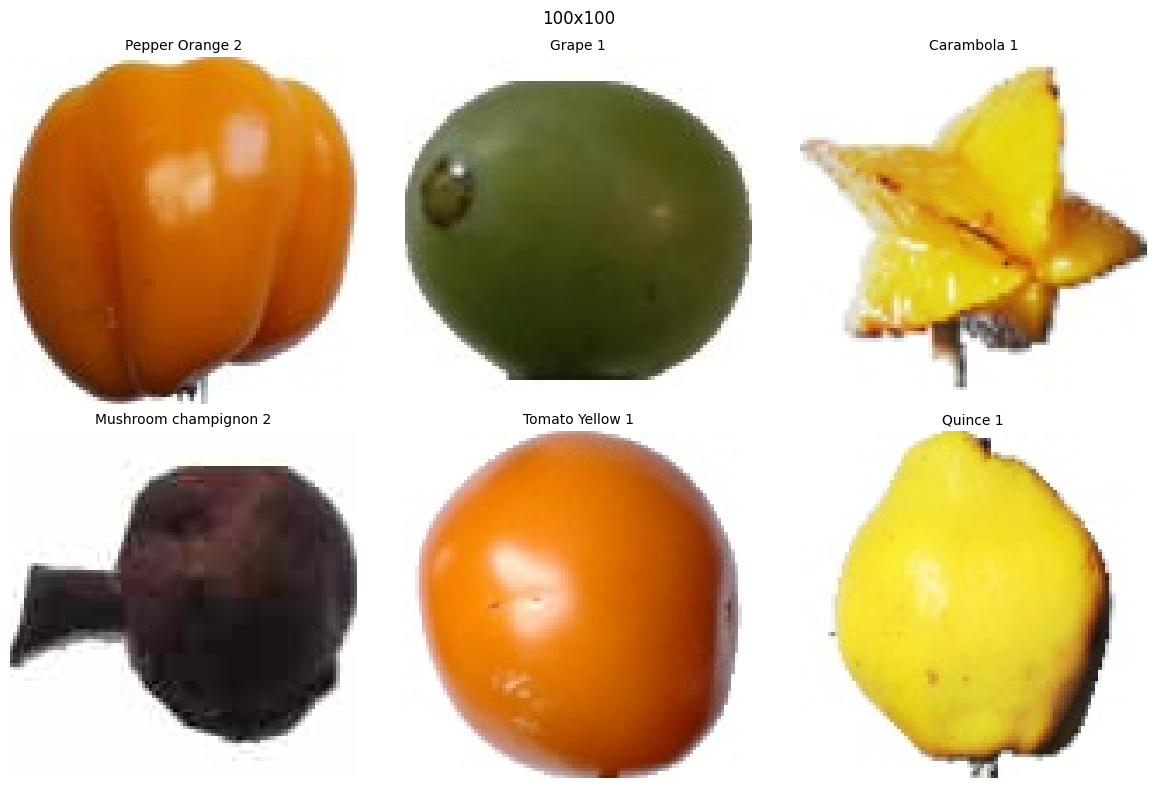

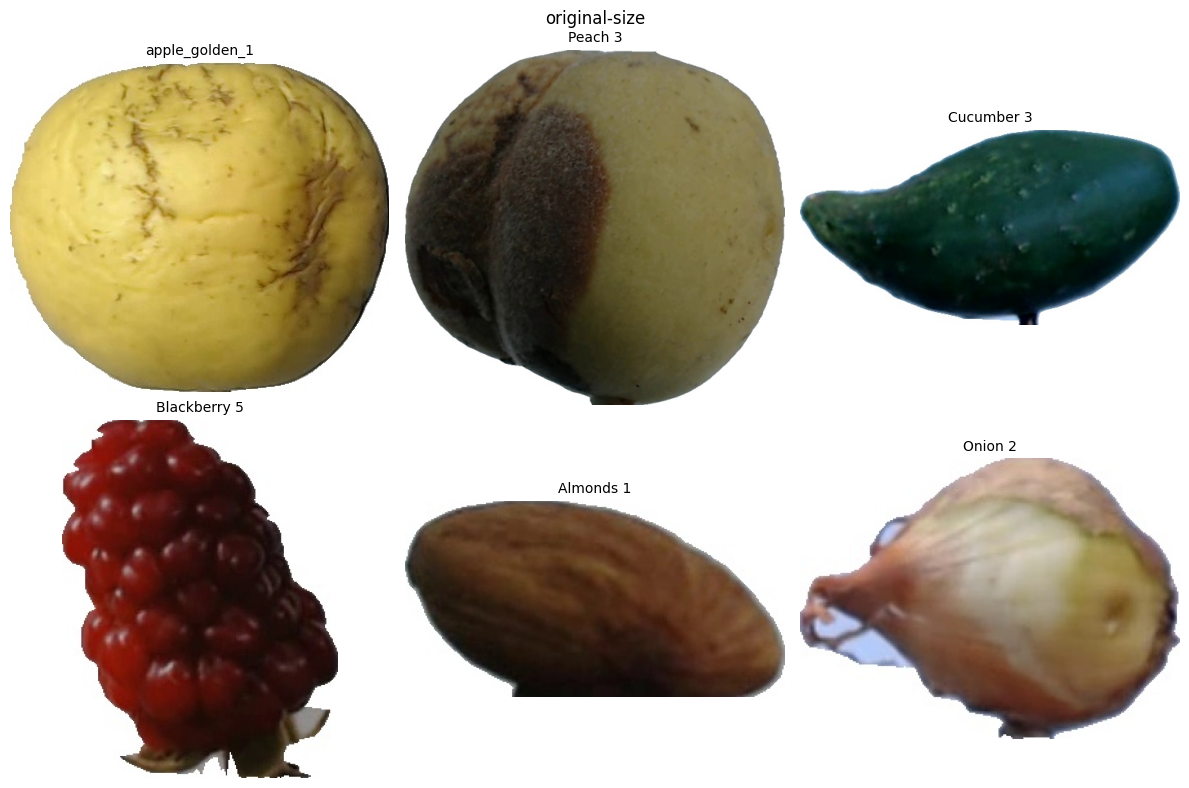

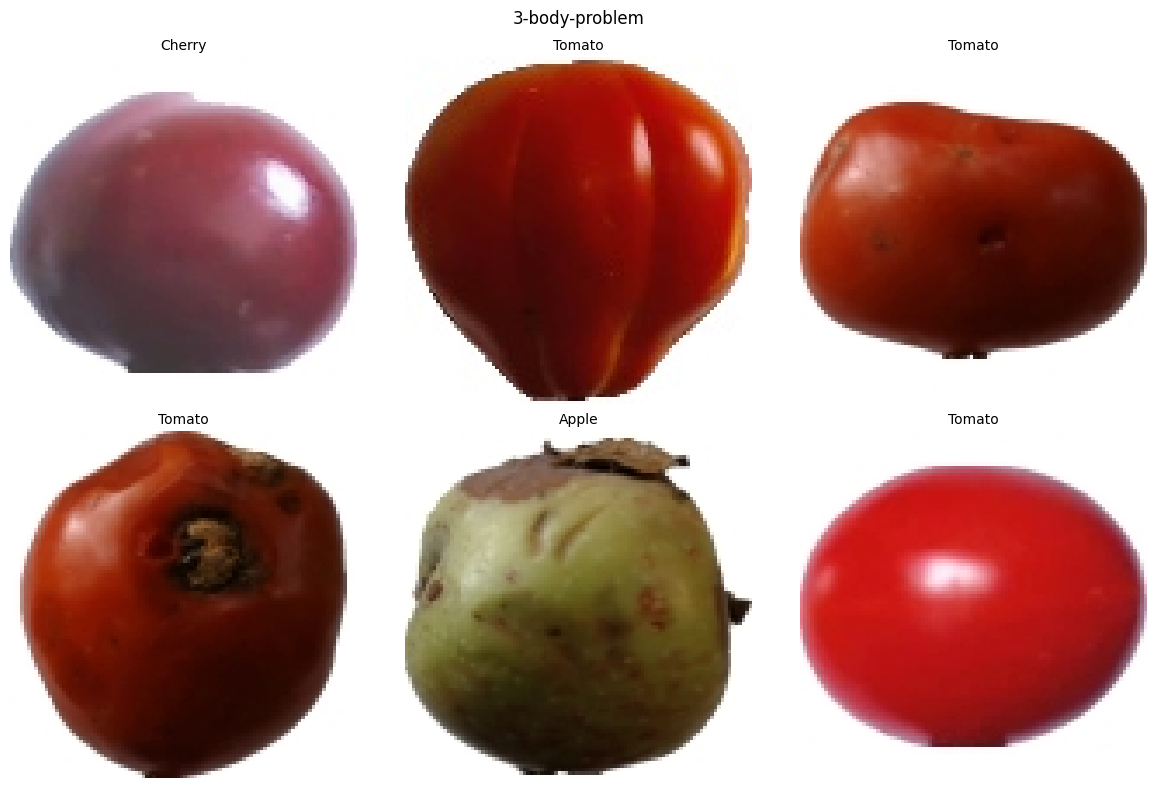

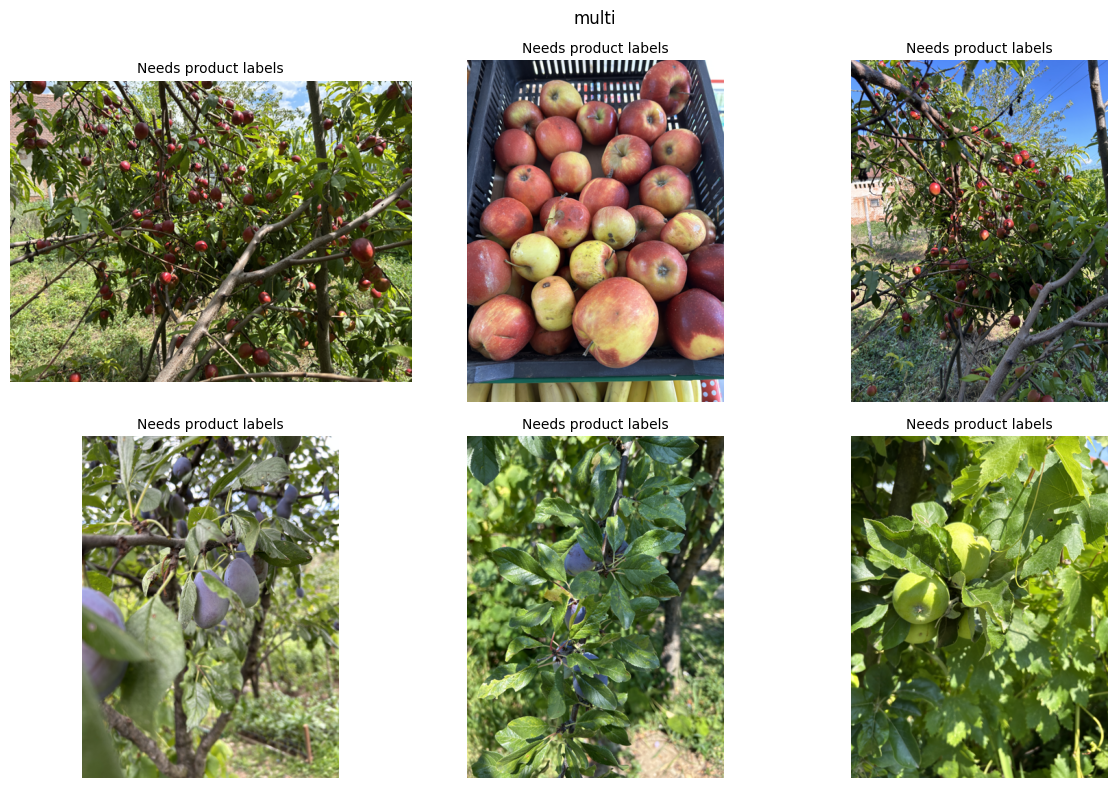

In [ ]:
preview_rows = []
for source in archive_names:
    table = images[images["source"] == source]
    if table.empty:
        continue
    sample = table.sample(n=min(6, len(table)), random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax in axes.flat:
        ax.axis("off")
    with zipfile.ZipFile(project / archive_names[source]) as archive:
        for ax, row in zip(axes.flat, sample.to_dict("records")):
            preview = {"source": source, "member": row["member"], "error": ""}
            try:
                if row["bytes"] > 50 * 1024 * 1024:
                    raise ValueError("Preview skipped: file larger than 50 MB")
                with Image.open(BytesIO(archive.read(row["member"]))) as original:
                    preview["width"], preview["height"] = original.size
                    if original.width * original.height > 40000000:
                        raise ValueError("Preview skipped: image larger than 40 megapixels")
                    image = ImageOps.exif_transpose(original).convert("RGB")
                    image.thumbnail((500, 500))
                    ax.imshow(image)
                    ax.set_title(row["source_label"] or "Needs product labels", fontsize=10)
            except Exception as error:
                preview["error"] = str(error)
                ax.set_title("Preview unavailable", fontsize=10)
            preview_rows.append(preview)
    fig.suptitle(source)
    plt.tight_layout()
    plt.savefig(report_path / (source + "_samples.png"), dpi=120)
    plt.show()
pd.DataFrame(preview_rows).to_csv(report_path / "preview_details.csv", index=False)

## 6. Export the audit report
Send the ZIP produced below for the next preparation step. It contains inventory tables, source notes, and small preview sheets, not the original image collection or model weights.

Before training: resolve resized duplicates and related capture groups across all sources; review and label useful multi-object crops; keep every crop and resolution variant of one source image in the same split; hold out representative real-world images; then freeze the combined data manifest. Do not move original Test examples into training while reporting the old test score as independent.

In [ ]:
summary = {
    "sources": sources.to_dict("records"),
    "exact_duplicate_groups": int(duplicates["sha256"].nunique()),
    "exact_duplicate_rows": len(duplicates),
    "unresolved_label_rows": int((label_table["status"] != "Candidate mapping").sum()),
    "ready_for_training": False,
    "remaining": ["resized-copy and capture-group review", "multi-object crop labeling", "unified split and independent external evaluation"]
}
(report_path / "audit_summary.json").write_text(json.dumps(summary, indent=2))
export_path = report_path.parent / (report_path.name + "_Dataset_Audit.zip")
with zipfile.ZipFile(export_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for file in report_path.iterdir():
        if file.is_file():
            archive.write(file, file.name)
print("AUDIT COMPLETE")
print(json.dumps(summary, indent=2))
print("Send this report ZIP:", export_path)

AUDIT COMPLETE
{
  "sources": [
    {
      "source": "100x100",
      "images": 184838,
      "zip_mb": 810.68,
      "uncompressed_image_mb": 797.35
    },
    {
      "source": "original-size",
      "images": 104444,
      "zip_mb": 3909.42,
      "uncompressed_image_mb": 3963.26
    },
    {
      "source": "3-body-problem",
      "images": 49236,
      "zip_mb": 284.15,
      "uncompressed_image_mb": 279.62
    },
    {
      "source": "multi",
      "images": 756,
      "zip_mb": 2384.3,
      "uncompressed_image_mb": 2387.68
    },
    {
      "source": "meta",
      "images": 0,
      "zip_mb": 0.32,
      "uncompressed_image_mb": 0.0
    }
  ],
  "exact_duplicate_groups": 47658,
  "exact_duplicate_rows": 96895,
  "unresolved_label_rows": 17,
  "ready_for_training": false,
  "remaining": [
    "resized-copy and capture-group review",
    "multi-object crop labeling",
    "unified split and independent external evaluation"
  ]
}
Send this report ZIP: /content/drive/MyDrive/ITI_